# Process Cam_08_23 water-depth scan: dose and charge density

Reads `Cam_08_23/08_23_conditions`, keeps only the `ININWATER*` rows (the
water-depth scan; drops `INOUTAIR`/`ININAIR`), derives a depth in mm from the
signed number in `ScatFlag` (`-4`→20mm, `+36`→60mm, `+76`→100mm, i.e.
`depth_mm = number + 24`), and locates each film's tif under
`Cam_08_23/<date>/<Film>.tif`. Both `Type == "EBT3"` and `Type == "EBTXD"`
films are processed, using the matching `CALIB` coefficients for each.

Dose uses the calibration relationship `d = a + b/(D-c)`, where `d` is net
optical density (`OD - OD0`) and `D` is dose, inverted to
`D = c + b/(d-a)`. These coefficients (`a_gx/b_gx/c_gx` for EBTXD,
`a_g3/b_g3/c_g3` for EBT3) are fit on the **green** channel (`channel=1`).
`nOD0` (background) comes from `Cam_08_23/1_09/EBT3-back.tif` /
`EBTXD-back.tif` -- the only unexposed scans in the dataset (cropped to
their central 50% first, since the background scans aren't centred and the
outer region isn't film). Charge density renormalises the dose map by each
row's `THz2` charge (nC), and is only computed for collimated shots
(`Col == True`) -- uncollimated shots skip straight past it. Dose and
charge-density figures/CSVs are written to separate output folders, same
convention as `CLEAR_RCF_processing.ipynb`.

Defaults worth checking before trusting the output:
`apply_remove_marking=False` (edge-marking cleanup is dataset-specific --
this batch hasn't been visually checked for it; turn it on and tune the
threshold if the profile fits look contaminated at the edges).

**Resolved:** an earlier version of this notebook assumed the same rational
calibration form as `dose_CLEAR` elsewhere in the project
(`D = (a - c*exp(-nOD))/(exp(-nOD)-b)`) on the red channel, which gave
uniformly negative dose -- `a/c` for these coefficients was nowhere near 1,
unlike every other calibration in the repo. That was the wrong functional
form. With the correct `d = a + b/(D-c)` model and the green channel, real
`Cam_08_23/30_08/D002-D004.tif` data gives positive, physically reasonable
doses (~9-26 Gy across the map, median ~18 Gy, for a ~4.4 nC shot).

In [26]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # RF_Track bundles its own libomp; harmless either way
                                              # but kept since it's the documented workaround for
                                              # the general duplicate-OpenMP-runtime warning.

# RF_Track MUST be imported before anything that pulls in scikit-learn (flatness.py, imported
# transitively below via YAG_RCF_analysis -> uniformity_fit, does `from sklearn.neighbors import
# NearestNeighbors`). Importing sklearn before RF_Track corrupts RF_Track's bundled OpenMP thread
# pool and segfaults (SIGSEGV in libomp's __kmp_fork_barrier) the first time RF_Track actually
# tracks a bunch -- reproduced and confirmed standalone, unrelated to Jupyter/VS Code. Importing
# RF_Track first avoids it entirely; both then work fine.
import RF_Track
from CLEAR_line import get_beamline

import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pandas as pd
from pathlib import Path
from PIL import Image
from scipy.optimize import curve_fit
from YAG_RCF_analysis import beam_centroid
from uniformity_fit import supergaussian2D_skewed

# ---- calibration coefficients dose = (a - c* OD)/(OD - b) ----
a_g3, b_g3, c_g3 = 1.36037090e-02, 1.48062223e-04, 5.72374622e+00   # EBT3
a_gx, b_gx, c_gx = 5.06620041e-02, 9.34532386e-05, 1.81500016e+01  # EBTXD

CALIB = {
    "EBT3": (a_g3, b_g3, c_g3),
    "EBTXD": (a_gx, b_gx, c_gx),
}

channel = 1                    # green -- these calibration coefficients are fit on the green channel
apply_remove_marking = False   # see markdown note above

data_root = Path("Cam_08_23")
conditions_path = data_root / "08_23_conditions"
background_dir = data_root / "1_09"  # EBT3-back.tif / EBTXD-back.tif live here

dose_fig_dir = data_root / "RCF_output_figs" / "dose"
cd_fig_dir = data_root / "RCF_output_figs" / "charge_density"
dose_csv_path = data_root / "water_depth_dose.csv"
cd_csv_path = data_root / "water_depth_charge_density.csv"

dose_fig_dir.mkdir(parents=True, exist_ok=True)
cd_fig_dir.mkdir(parents=True, exist_ok=True)

In [27]:
def get_calibration(im_type):
    if im_type == "RCF":
        return 0.0846667  # mm/pixel


def load_channel(path, channel=channel):
    return np.array(Image.open(path).convert('RGB'))[..., channel].astype(float)


def remove_marking(film, threshold=12000, fill=35000, edge=65):
    """Optional edge-marking cleanup, same technique as RCF_processing.ipynb.
    Off by default (apply_remove_marking=False) -- tune threshold/fill/edge for
    this dataset before turning on."""
    h, w = film.shape
    mask = np.ones((h, w), dtype=bool)
    mask[edge:-edge, :] = False
    film[mask & (film < threshold)] = fill
    return film


def dose_from_calib(PV, a, b, c):
    """Calibration: D = (a - c*exp_term) / (exp_term - b), exp_term = PV/65535."""
    exp_term = PV / 65535
    return (a - c * exp_term) / (exp_term - b)


def dose_at_centre(dosemap, im_type, x, y, r_mm=2.0):
    """Just the 2D-fit part of plot_dose1 (YAG_RCF_analysis.py): locate the
    beam centre with a 2D skewed SuperGaussian fit, then report the mean
    dose/charge-density within r_mm of it. Skips plot_dose1's 1D SuperGaussian
    and 2-Gaussian slice fits entirely -- not needed here."""
    cx_idx, cy_idx = beam_centroid(dosemap)
    x_c, y_c = x - x[cx_idx], y - y[cy_idx]

    xx, yy = np.meshgrid(x_c, y_c)
    X = np.vstack((xx.ravel(), yy.ravel()))
    Z = dosemap.ravel()
    dx = np.mean(np.diff(x_c))
    dy = np.mean(np.diff(y_c))

    A0 = float(np.nanmax(dosemap) - np.nanmin(dosemap))
    c0 = float(np.nanmin(dosemap))
    p0_2d = [A0, 0.0, 0.0, 5.0, 5.0, 2.0, 2.0, 0.0, 0.0, c0]
    lower = [0.0, -np.inf, -np.inf, 1e-6, 1e-6, 1.0, 1.0, -np.inf, -np.inf, -np.inf]
    upper = [np.inf, np.inf, np.inf, np.inf, np.inf, 20.0, 20.0, np.inf, np.inf, np.inf]
    params_2d, _ = curve_fit(supergaussian2D_skewed, X, Z, p0=p0_2d, bounds=(lower, upper))
    A, x0, y0, sig_x2d, sig_y2d, P_x2d, P_y2d, mx, my, c = params_2d

    new_x, new_y = x_c - x0, y_c - y0
    new_cx_idx = int(round(cx_idx + x0 / dx))
    new_cy_idx = int(round(cy_idx + y0 / dy))

    xxn, yyn = np.meshgrid(new_x, new_y)
    circle_mask = (xxn ** 2 + yyn ** 2) <= r_mm ** 2
    if np.any(circle_mask):
        centre = float(np.mean(dosemap[circle_mask]))
        std = float(np.std(dosemap[circle_mask]))
    else:
        centre = np.nan
        std = np.nan

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(dosemap, origin="lower", aspect="equal", cmap="viridis",
                    extent=[new_x[0], new_x[-1], new_y[0], new_y[-1]])
    ax.add_patch(Circle((0, 0), r_mm, fill=False, linestyle=":", linewidth=1.8, edgecolor="white"))
    unit = {"RCF": "Gy", "YAG": "pC/mm²", "OD": "OD"}.get(im_type, "")
    ax.text(0.35, -3, f"Mean = {centre:.2f} ± {std:.2f} {unit}",
            color="white", fontsize=10, va="center", ha="left",
            bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=2))
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

    return fig, new_cx_idx, new_cy_idx, centre, std

In [28]:
def central_crop(img, frac=0.5):
    """Crop to the central `frac` extent along each axis (e.g. 0.5 -> middle 50%),
    discarding the margins. Used for the background films, which aren't centred
    in the scan so the outer region isn't film."""
    h, w = img.shape
    margin_frac = (1 - frac) / 2
    h0, h1 = int(h * margin_frac), int(h * (1 - margin_frac))
    w0, w1 = int(w * margin_frac), int(w * (1 - margin_frac))
    return img[h0:h1, w0:w1]


nOD0_by_type = {}
for film_type, back_name in [("EBT3", "EBT3-back"), ("EBTXD", "EBTXD-back")]:
    back = load_channel(background_dir / f"{back_name}.tif")
    back_central = central_crop(back, frac=0.5)
    OD0 = -np.log(np.median(back_central) / 65535)
    nOD0_by_type[film_type] = OD0
    print(f"{film_type}: background {back_name}.tif  OD0={OD0:.4f}")

EBT3: background EBT3-back.tif  OD0=6.0341
EBTXD: background EBTXD-back.tif  OD0=5.9086


In [29]:
conditions = pd.read_csv(conditions_path)
water = conditions[conditions["ScatFlag"].str.startswith("ININWATER")].copy()

water["folder"] = water["date"].str.rstrip("/")
water["depth_mm"] = water["ScatFlag"].str.extract(r"ININWATER([+-]\d+)")[0].astype(int) + 24

water[["Film", "ScatFlag", "depth_mm", "Type", "folder", "THz2", "Col"]]

,Film,ScatFlag,depth_mm,Type,folder,THz2,Col
2,A006,ININWATER-4,20,EBT3,29_08,3.74,False
3,A007,ININWATER+36,60,EBT3,29_08,3.82,False
4,A008,ININWATER+76,100,EBT3,29_08,3.75,False
6,A011,ININWATER-4,20,EBT3,29_08,3.32,False
7,A012,ININWATER+36,60,EBT3,29_08,3.39,False
...,...,...,...,...,...,...,...
96,D027,ININWATER+36,60,EBTXD,1_09,1.92,False
97,D028,ININWATER+76,100,EBTXD,1_09,1.97,False
99,D031,ININWATER-4,20,EBTXD,1_09,0.45,True
100,D032,ININWATER+36,60,EBTXD,1_09,0.44,True


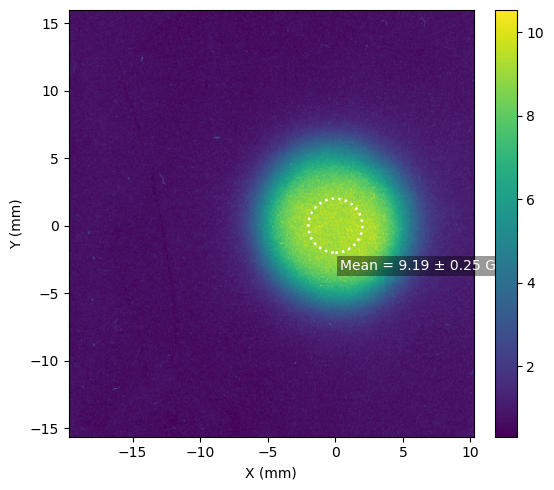

D003: centre dose = 9.1869 ± 0.2530


In [47]:
# Quick diagnostic: raw OD image + 2D-fit centre value for D003 (EBT3), independent of the dose calibration
row = conditions[conditions["Film"] == "D003"].iloc[0]
tif_path = data_root / row["date"].rstrip("/") / "D003.tif"
film_flipped = np.flipud(load_channel(tif_path))[35:-60, 30:-30]  # crop to remove the scan edges, which are not film
OD = -np.log(film_flipped / 65535)

h, w = film_flipped.shape
diag_pixel_calibration = get_calibration("RCF")
x = np.arange(w) * diag_pixel_calibration
y = np.arange(h) * diag_pixel_calibration

dose = dose_from_calib(film_flipped, *CALIB[row["Type"]])

fig, cx, cy, centre, std = dose_at_centre(dose, "RCF", x, y)
plt.show()
print(f"D003: centre dose = {centre:.4f} ± {std:.4f}")

In [48]:
def load_done(csv_path):
    done = set()
    if csv_path.exists() and csv_path.stat().st_size > 0:
        with open(csv_path, "r", newline="") as f:
            reader = csv.reader(f)
            next(reader, None)  # skip header
            for row in reader:
                if row:
                    done.add(row[0])
    return done


header = ["film", "date", "type", "col", "depth_mm", "THz2_nC", "cx", "cy", "centre", "std"]

dose_done = load_done(dose_csv_path)
cd_done = load_done(cd_csv_path)

write_dose_header = not dose_csv_path.exists() or dose_csv_path.stat().st_size == 0
write_cd_header = not cd_csv_path.exists() or cd_csv_path.stat().st_size == 0

pixel_calibration = get_calibration("RCF")
pixel_area_mm2 = pixel_calibration ** 2

with open(dose_csv_path, "a", newline="") as fd, open(cd_csv_path, "a", newline="") as fc:
    dose_writer = csv.writer(fd)
    cd_writer = csv.writer(fc)
    if write_dose_header:
        dose_writer.writerow(header)
    if write_cd_header:
        cd_writer.writerow(header)

    for _, row in water.iterrows():
        film_name = row["Film"]

        need_dose = film_name not in dose_done
        need_cd = bool(row["Col"]) and film_name not in cd_done  # charge density only for collimated shots
        if not need_dose and not need_cd:
            print(f"Skipping {film_name}: already processed")
            continue

        film_type = row["Type"]
        a, b, c = CALIB[film_type]

        tif_path = data_root / row["folder"] / f"{film_name}.tif"
        film = load_channel(tif_path)
        if apply_remove_marking:
            film = remove_marking(film)
        film_flipped = np.flipud(film)

        h, w = film_flipped.shape
        x = np.arange(w) * pixel_calibration
        y = np.arange(h) * pixel_calibration

        dose = dose_from_calib(film_flipped, a, b, c)
        meta = [film_name, row["folder"], film_type, row["Col"], row["depth_mm"], row["THz2"]]

        # -- dose map --
        if need_dose:
            try:
                fig, cx, cy, centre, std = dose_at_centre(dose, "RCF", x, y)
                fig.savefig(dose_fig_dir / f"{film_name}_dose_profile.png", dpi=300, bbox_inches="tight")
                plt.close(fig)
                dose_writer.writerow(meta + [cx, cy, centre, std])
                fd.flush()
            except Exception as e:
                print(f"Failed dose_at_centre on {film_name}: {e}")
                try:
                    plt.close(fig)
                except Exception:
                    pass

        # -- charge density map (renormalised by this film's THz2 charge), collimated shots only.
        # Cropped [25:-40, 30:-30] here (dose map above stays uncropped) to exclude edge/marking
        # artifacts from the total_dose normalization integral. --
        if need_cd:
            dose_cd = dose[35:-60, 30:-30]
            x_cd = x[30:-30]
            y_cd = y[35:-60]

            Q_total_pC = row["THz2"] * 1000  # nC -> pC
            total_dose = np.sum(dose_cd)
            charge_density = dose_cd * Q_total_pC / total_dose / pixel_area_mm2

            try:
                fig, cx, cy, centre, std = dose_at_centre(charge_density, "YAG", x_cd, y_cd)
                fig.savefig(cd_fig_dir / f"{film_name}_charge_density_profile.png", dpi=300, bbox_inches="tight")
                plt.close(fig)
                cd_writer.writerow(meta + [cx, cy, centre, std])
                fc.flush()
            except Exception as e:
                print(f"Failed dose_at_centre on {film_name}: {e}")
                try:
                    plt.close(fig)
                except Exception:
                    pass

        print(f"Processed {film_name} ({film_type}, depth={row['depth_mm']}mm, THz2={row['THz2']}nC)")

Skipping A006: already processed
Skipping A007: already processed
Skipping A008: already processed
Skipping A011: already processed
Skipping A012: already processed
Skipping A013: already processed
Processed A018 (EBT3, depth=20mm, THz2=0.93nC)
Failed dose_at_centre on A019: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Processed A019 (EBT3, depth=60mm, THz2=0.94nC)
Processed A020 (EBT3, depth=100mm, THz2=0.93nC)
Skipping A023: already processed
Skipping A024: already processed
Failed dose_at_centre on A025: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Processed A025 (EBT3, depth=100mm, THz2=9.08nC)
Processed A030 (EBT3, depth=20mm, THz2=2.43nC)
Processed A031 (EBT3, depth=60mm, THz2=2.48nC)
Processed A032 (EBT3, depth=100mm, THz2=2.44nC)
Processed C007 (EBT3, depth=20mm, THz2=2.59nC)
Processed C008 (EBT3, depth=60mm, THz2=2.46nC)
Processed C009 (EBT3, depth=100mm, THz2=2.5nC)
Skipping C013: already proces

## Simulation: RF_Track + TOPAS for the ININWATER collimated/uncollimated cases

Mirrors `simulate_PDD_CLEAR.ipynb`'s dual-scatterer pipeline (RF_Track
tracking from `QFD0760`'s entrance -> phase-space export -> TOPAS) for each
distinct `(Quads, Col)` combination that appears among the `ININWATER*` rows,
at each of the three water depths (20/60/100mm).

- Twiss at `QFD0760`'s entrance, 200 MeV: β=5.45/22.54 m, α=0.18/0.58,
  normalised ε=12.9/8.5 mm·mrad.
- `Quads` decodes to two currents: the first two digits are `QFD0760`, the
  last two are `QDD0765` (e.g. `4447` -> 44A/47A). `QFD0770` is fixed at 0A.
- S1/S2/collimator/YAG/tank geometry is copied verbatim from
  `simulate_PDD_CLEAR.ipynb`'s dual-scatterer cell, using its "large" S2
  option (`s2_thickness=[0.688,0.778,0.581,0.386]`,
  `s2_radii=[0.4,0.8,1.2,1.6]`, paired with `s2_width=1.6, s2_depth=2.43` --
  the pairing used together in that notebook's `_0820_large_*` cells). The
  collimator (`add_collimator(50,15,5,50,...)`) is only added when
  `Col=True`.

In [16]:

from CLEAR_line import get_beamline
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from YAG_RCF_analysis import plot_dose1

survey_file = "CLEAR_Beamline_Survey.txt"
sim_start, sim_end = "CA.QFD0760", "CA.DHJ0840"
sim_depths_mm = [20]  # TODO: add 60/100 back for the full run

In [17]:
sim_conditions = conditions[conditions["ScatFlag"].str.startswith("ININWATER")].copy()
sim_configs = sim_conditions[["Quads", "Col"]].drop_duplicates().reset_index(drop=True)

quads_str = sim_configs["Quads"].astype(int).astype(str)
sim_configs["I_QFD760"] = quads_str.str[:2].astype(float)
sim_configs["I_QDD765"] = quads_str.str[2:].astype(float)
sim_configs["I_QFD770"] = 0.0

sim_configs["P_ref"] = 200.0
sim_configs["beta_x"], sim_configs["beta_y"] = 5.45, 22.54
sim_configs["alpha_x"], sim_configs["alpha_y"] = 0.18, 0.58
sim_configs["emitt_x"], sim_configs["emitt_y"] = 12.9, 8.5  # mm.mrad, normalised

sim_configs

,Quads,Col,I_QFD760,I_QDD765,I_QFD770,P_ref,beta_x,beta_y,alpha_x,alpha_y,emitt_x,emitt_y
0,4447,False,44.0,47.0,0.0,200.0,5.45,22.54,0.18,0.58,12.9,8.5
1,4447,True,44.0,47.0,0.0,200.0,5.45,22.54,0.18,0.58,12.9,8.5
2,3336,True,33.0,36.0,0.0,200.0,5.45,22.54,0.18,0.58,12.9,8.5
3,3336,False,33.0,36.0,0.0,200.0,5.45,22.54,0.18,0.58,12.9,8.5
4,3839,True,38.0,39.0,0.0,200.0,5.45,22.54,0.18,0.58,12.9,8.5
5,3839,False,38.0,39.0,0.0,200.0,5.45,22.54,0.18,0.58,12.9,8.5


### Single-condition test run

Same three stages as the full loop below (RF_Track tracking -> TOPAS
geometry+run -> getDosemap/plot_dose1 post-processing), but for just one
config, split into separate cells so each stage can be run and inspected
(or crash) independently. Useful for isolating which stage the kernel
crash is actually coming from before running the full loop.

In [ ]:
# -- Stage 1: RF_Track tracking for ONE config (first collimated one) --
mass = RF_Track.electronmass
population = 10 * RF_Track.nC
Q = -1
n_particles = int(5e5)
RFT_name = "CLEAR_line"
sim_dir = "/Users/sabrinawang/Desktop/DPhil_Project/"

test_cfg = sim_configs[sim_configs["Col"]].iloc[0]
test_depth = sim_depths_mm[0]
print(test_cfg)

# test_cfg is a pandas row -- every field below comes back as numpy.float64, not a plain
# Python float. Not actually the cause of the earlier crash (that was the sklearn-before-
# RF_Track import order, fixed in the first cell), but cast to float() anyway as cheap
# defensive practice before handing values to RF_Track's C++ bindings.
Twiss = RF_Track.Bunch6d_twiss()
Twiss.beta_x, Twiss.beta_y = float(test_cfg["beta_x"]), float(test_cfg["beta_y"])
Twiss.alpha_x, Twiss.alpha_y = float(test_cfg["alpha_x"]), float(test_cfg["alpha_y"])
Twiss.emitt_x, Twiss.emitt_y = float(test_cfg["emitt_x"]), float(test_cfg["emitt_y"])
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0
P_ref = float(test_cfg["P_ref"])

# quad_currents is indexed by the FULL beamline's quad order (11 quads);
# only indices 6/7/8 (QFD0760/QDD0765/QFD0770) matter since the lattice
# starts at QFD0760.
quad_currents = [0.0] * 11
quad_currents[6] = float(test_cfg["I_QFD760"])
quad_currents[7] = float(test_cfg["I_QDD765"])
quad_currents[8] = float(test_cfg["I_QFD770"])

CLEAR_lattice = get_beamline(survey_file, sim_start, sim_end, P_ref, quad_currents, Q=Q)

B0 = RF_Track.Bunch6d_QR(mass, population, Q, P_ref, Twiss, n_particles)
B1 = CLEAR_lattice.track(B0)
R = B1.get_phase_space('%x %xp %y %yp %E %z')
print("Tracking done, R shape:", R.shape)

In [ ]:
# -- Stage 2: build the TOPAS geometry for this one config+depth and run it --
s1_pos = 84
s1_l = 0.1
s2_width, s2_depth = 1.6, 2.43           # "large" pairing (matches sum(s2_thickness) below)
s2_thickness = [0.688, 0.778, 0.581, 0.386]
s2_radii = [0.4, 0.8, 1.2, 1.6]          # large

col_tag = "col" if test_cfg["Col"] else "uncol"
test_output_filename = f"Cam0823_Q{int(test_cfg['Quads'])}_{col_tag}_d{test_depth}"
test_dose_file = f"DoseAtTank{test_depth}_{test_output_filename}.csv"

if not os.path.exists(test_dose_file):
    setup = partrec_gaussian_optimiser_utils()
    setup.export_phsp(R, sim_dir + RFT_name + '.phsp')
    setup.write_header(R, sim_dir + RFT_name + '.header')
    setup.import_beam_topas(sim_dir + RFT_name, position=0)

    setup.add_flat_scatterer(s1_l, 'Aluminum', s1_pos)

    for i in range(len(s2_thickness)):
        sname = 'S2_slice_' + str(i)
        slice_position = s1_pos + s1_l + 532 + sum(s2_thickness[:i - 1])
        setup.add_cylinder(sname, s2_thickness[i - 1], 0, s2_radii[i - 1], 'Peek', slice_position)

    setup.add_cylinder('kapton_holder', 0.025, 0, 33, "kapton", s1_pos + 532 + s1_l + sum(s2_thickness) + 0.025)
    setup.add_cylinder("vacuum_window", 0.075, 0, 500, "kapton", s1_pos + 532 + s1_l + sum(s2_thickness) + 1489)

    if test_cfg["Col"]:
        setup.add_collimator(50, 15, 5, 50, s1_pos + s1_l + 532 + s2_depth + 1585)

    setup.add_box("YAG", 0.55, 35, 40, "YAG", s1_pos + 532 + s1_l + sum(s2_thickness) + 1939, rotation=45)
    setup.add_box("air2", 70, 100, 100, "Air", s1_pos + 532 + s1_l + sum(s2_thickness) + 1953)
    setup.add_cylinder('tank_window', 0.075, 0, 100, "kapton", s1_pos + 532 + s1_l + sum(s2_thickness) + 2024)

    setup.add_tank_bins(s1_pos + 532 + s1_l + sum(s2_thickness) + 2025, test_depth, 100, 100, 1, test_output_filename, width=30)

    print(f"Running {test_output_filename}")
    setup.run_topas(view_setup=False)
    print("TOPAS run done")
else:
    print(f"{test_dose_file} already exists, skipping TOPAS run")

In [ ]:
# -- Stage 3: post-process with getDosemap/plot_dose1 -- dose map from THz1, charge density
# from THz2 (only since this test config is collimated) --
sim_conditions["depth_mm"] = sim_conditions["ScatFlag"].str.extract(r"ININWATER([+-]\d+)")[0].astype(int) + 24
test_matches = sim_conditions[
    (sim_conditions["Quads"] == test_cfg["Quads"]) &
    (sim_conditions["Col"] == test_cfg["Col"]) &
    (sim_conditions["depth_mm"] == test_depth)
]
print(test_matches[["Film", "THz1", "THz2"]])

test_film_row = test_matches.iloc[0]
test_thz1 = test_film_row["THz1"]
test_thz2 = test_film_row["THz2"]

x, y, doseMap = getDosemap(
    test_dose_file, n_particles, dose_depth=test_depth,
    outputFileName=test_output_filename, acChargenC=test_thz1, plot=False
)
print("getDosemap done")

fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1(doseMap, "RCF", x, y, strip_width=2)
plt.show()
print(f"{test_film_row['Film']}: dose_centre={dose_centre:.4f}")

if test_cfg["Col"]:
    Q_total_pC = test_thz2 * 1000  # nC -> pC
    pixel_area_mm2 = np.mean(np.diff(x)) * np.mean(np.diff(y))
    total_dose = np.sum(doseMap)
    chargeDensityMap = doseMap * Q_total_pC / total_dose / pixel_area_mm2

    fig, cx, cy, CD_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, CD_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1(chargeDensityMap, "RCF", x, y, strip_width=2)
    plt.show()
    print(f"{test_film_row['Film']}: CD_centre={CD_centre:.4f}")

In [20]:
mass = RF_Track.electronmass
population = 10 * RF_Track.nC
Q = -1
n_particles = int(5e5)
RFT_name = "CLEAR_line"
sim_dir = "/Users/sabrinawang/Desktop/DPhil_Project/"

# S1/S2 geometry, copied from simulate_PDD_CLEAR.ipynb's dual-scatterer cell
s1_pos = 84
s1_l = 0.1
s2_width, s2_depth = 1.6, 2.43           # "large" pairing (matches sum(s2_thickness) below)
s2_thickness = [0.688, 0.778, 0.581, 0.386]
s2_radii = [0.4, 0.8, 1.2, 1.6]          # large

# Collimated configs first
sim_configs = sim_configs.sort_values("Col", ascending=False).reset_index(drop=True)

# Match each (Quads, Col, depth) to every film shot taken at that config -- TOPAS only runs
# once per config+depth, but post-processing (getDosemap/plot_dose1) runs once per shot, using
# that shot's own THz1 (dose) / THz2 (charge density), same convention as simulate_PDD_CLEAR.ipynb.
# Uses sim_conditions (not water) since it isn't restricted to Type=="EBTXD" -- some Quads values
# (e.g. 3336) only have EBT3 shots, which water excludes.
sim_conditions["depth_mm"] = sim_conditions["ScatFlag"].str.extract(r"ININWATER([+-]\d+)")[0].astype(int) + 24

sim_fig_dir = data_root / "Simulations"
sim_csv_path = data_root / "water_depth_sim_dose.csv"
sim_cd_csv_path = data_root / "water_depth_sim_charge_density.csv"
sim_fig_dir.mkdir(parents=True, exist_ok=True)

sim_header = [
    "film", "Quads", "Col", "depth_mm", "charge_nC",
    "cx", "cy", "centre", "P_x", "P_y",
    "r90_x", "r90_y", "ratio_x", "ratio_y", "std",
    "errPx", "errPy", "err_x90_x", "err_x90_y", "err_ratio_x", "err_ratio_y"
]

dose_done = load_done(sim_csv_path)
cd_done = load_done(sim_cd_csv_path)
write_dose_header = not sim_csv_path.exists() or sim_csv_path.stat().st_size == 0
write_cd_header = not sim_cd_csv_path.exists() or sim_cd_csv_path.stat().st_size == 0

with open(sim_csv_path, "a", newline="") as fdose, open(sim_cd_csv_path, "a", newline="") as fcd:
    dose_writer = csv.writer(fdose)
    cd_writer = csv.writer(fcd)
    if write_dose_header:
        dose_writer.writerow(sim_header)
    if write_cd_header:
        cd_writer.writerow(sim_header)

    for _, cfg in sim_configs.iterrows():
        # cfg is a pandas row -- every field below comes back as numpy.float64, not a plain
        # Python float. Not actually the cause of the earlier crash (that was the sklearn-before-
        # RF_Track import order, fixed in the first cell), but cast to float() anyway as cheap
        # defensive practice before handing values to RF_Track's C++ bindings.
        Twiss = RF_Track.Bunch6d_twiss()
        Twiss.beta_x, Twiss.beta_y = float(cfg["beta_x"]), float(cfg["beta_y"])
        Twiss.alpha_x, Twiss.alpha_y = float(cfg["alpha_x"]), float(cfg["alpha_y"])
        Twiss.emitt_x, Twiss.emitt_y = float(cfg["emitt_x"]), float(cfg["emitt_y"])
        Twiss.mean_xp = 0.0
        Twiss.mean_yp = 0.0
        P_ref = float(cfg["P_ref"])

        # quad_currents is indexed by the FULL beamline's quad order (11 quads);
        # only indices 6/7/8 (QFD0760/QDD0765/QFD0770) matter since the lattice
        # starts at QFD0760.
        quad_currents = [0.0] * 11
        quad_currents[6] = float(cfg["I_QFD760"])
        quad_currents[7] = float(cfg["I_QDD765"])
        quad_currents[8] = float(cfg["I_QFD770"])

        CLEAR_lattice = get_beamline(survey_file, sim_start, sim_end, P_ref, quad_currents, Q=Q)

        B0 = RF_Track.Bunch6d_QR(mass, population, Q, P_ref, Twiss, n_particles)
        B1 = CLEAR_lattice.track(B0)
        R = B1.get_phase_space('%x %xp %y %yp %E %z')

        for depth in sim_depths_mm:
            col_tag = "col" if cfg["Col"] else "uncol"
            output_filename = f"Cam0823_Q{int(cfg['Quads'])}_{col_tag}_d{depth}"
            dose_file = f"DoseAtTank{depth}_{output_filename}.csv"

            matches = sim_conditions[
                (sim_conditions["Quads"] == cfg["Quads"]) &
                (sim_conditions["Col"] == cfg["Col"]) &
                (sim_conditions["depth_mm"] == depth)
            ]

            if not os.path.exists(dose_file):
                setup = partrec_gaussian_optimiser_utils()
                setup.export_phsp(R, sim_dir + RFT_name + '.phsp')
                setup.write_header(R, sim_dir + RFT_name + '.header')
                setup.import_beam_topas(sim_dir + RFT_name, position=0)

                setup.add_flat_scatterer(s1_l, 'Aluminum', s1_pos)

                for i in range(len(s2_thickness)):
                    sname = 'S2_slice_' + str(i)
                    slice_position = s1_pos + s1_l + 532 + sum(s2_thickness[:i - 1])
                    setup.add_cylinder(sname, s2_thickness[i - 1], 0, s2_radii[i - 1], 'Peek', slice_position)

                setup.add_cylinder('kapton_holder', 0.025, 0, 33, "kapton", s1_pos + 532 + s1_l + sum(s2_thickness) + 0.025)
                setup.add_cylinder("vacuum_window", 0.075, 0, 500, "kapton", s1_pos + 532 + s1_l + sum(s2_thickness) + 1489)

                if cfg["Col"]:
                    setup.add_collimator(50, 15, 5, 50, s1_pos + s1_l + 532 + s2_depth + 1585)

                setup.add_box("YAG", 0.55, 35, 40, "YAG", s1_pos + 532 + s1_l + sum(s2_thickness) + 1939, rotation=45)
                setup.add_box("air2", 70, 100, 100, "Air", s1_pos + 532 + s1_l + sum(s2_thickness) + 1953)
                setup.add_cylinder('tank_window', 0.075, 0, 100, "kapton", s1_pos + 532 + s1_l + sum(s2_thickness) + 2024)

                setup.add_tank_bins(s1_pos + 532 + s1_l + sum(s2_thickness) + 2025, depth, 100, 100, 1, output_filename, width=30)

                print(f"Running {output_filename}")
                setup.run_topas(view_setup=False)

            # -- post-process once per matching film shot: dose map from THz1, charge density
            # from THz2 (collimated shots only), same getDosemap/plot_dose1 pattern as
            # simulate_PDD_CLEAR.ipynb --
            for _, film_row in matches.iterrows():
                film_name = film_row["Film"]
                thz1 = film_row["THz1"]
                thz2 = film_row["THz2"]

                need_dose = film_name not in dose_done
                need_cd = bool(cfg["Col"]) and film_name not in cd_done
                if not need_dose and not need_cd:
                    print(f"Skipping {film_name}: already processed")
                    continue

                x, y, doseMap = getDosemap(
                    dose_file, n_particles, dose_depth=depth,
                    outputFileName=output_filename, acChargenC=thz1, plot=False
                )

                if need_dose:
                    fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1(doseMap, "RCF", x, y, strip_width=2)
                    fig.savefig(sim_fig_dir / f"{film_name}_dose_map.png", dpi=300, bbox_inches="tight")
                    plt.close(fig)
                    dose_writer.writerow([
                        film_name, int(cfg["Quads"]), bool(cfg["Col"]), depth, thz1,
                        cx, cy, dose_centre, Px, Py,
                        x90_x, x90_y, ratio_x, ratio_y, dose_std,
                        errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y
                    ])
                    fdose.flush()
                    dose_done.add(film_name)

                if need_cd:
                    Q_total_pC = thz2 * 1000  # nC -> pC
                    pixel_area_mm2 = np.mean(np.diff(x)) * np.mean(np.diff(y))
                    total_dose = np.sum(doseMap)
                    chargeDensityMap = doseMap * Q_total_pC / total_dose / pixel_area_mm2

                    fig, cx, cy, CD_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, CD_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1(chargeDensityMap, "YAG", x, y, strip_width=2)
                    fig.savefig(sim_fig_dir / f"{film_name}_charge_density_map.png", dpi=300, bbox_inches="tight")
                    plt.close(fig)
                    cd_writer.writerow([
                        film_name, int(cfg["Quads"]), bool(cfg["Col"]), depth, thz2,
                        cx, cy, CD_centre, Px, Py,
                        x90_x, x90_y, ratio_x, ratio_y, CD_std,
                        errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y
                    ])
                    fcd.flush()
                    cd_done.add(film_name)

                print(f"Processed {film_name} (Quads={int(cfg['Quads'])}, Col={bool(cfg['Col'])}, depth={depth}mm, THz1={thz1}nC, THz2={thz2}nC)")


Processed A018 (Quads=4447, Col=True, depth=20mm, THz1=3.78nC, THz2=0.93nC)
Processed A030 (Quads=4447, Col=True, depth=20mm, THz1=9.9nC, THz2=2.43nC)
Processed D002 (Quads=4447, Col=True, depth=20mm, THz1=18.09nC, THz2=4.41nC)
Processed F009 (Quads=4447, Col=True, depth=20mm, THz1=34.9nC, THz2=9.5nC)
Processed F022 (Quads=4447, Col=True, depth=20mm, THz1=21.8nC, THz2=5.3nC)
Processed C007 (Quads=3336, Col=True, depth=20mm, THz1=8.69nC, THz2=2.59nC)
Processed F032 (Quads=3839, Col=True, depth=20mm, THz1=39.8nC, THz2=12.4nC)
Processed E014 (Quads=3839, Col=True, depth=20mm, THz1=20.2nC, THz2=5.2nC)
Processed D021 (Quads=3839, Col=True, depth=20mm, THz1=20.3nC, THz2=6.2nC)
Processed D031 (Quads=3839, Col=True, depth=20mm, THz1=2.07nC, THz2=0.45nC)
Skipping A006: already processed
Skipping A011: already processed
Skipping A023: already processed
Skipping D007: already processed
Skipping F004: already processed
Skipping F015: already processed
Skipping C013: already processed
Skipping E002